# ECON 5140: Applied Econometrics
## Homework 3: Causal Inference — Potential Outcomes & Matching

---

# PART 1: ANALYTICAL PROBLEMS

### Problem 1: Potential Outcomes and Causal Estimands

Consider the following data from 8 individuals. D = 1 if they received job training; D = 0 if not. Y(1) and Y(0) are potential outcomes (earnings in thousands).

| i | Y(1) | Y(0) | D | Y_obs |
|---|------|------|---|-------|
| 1 | 45   | 35   | 1 | 45    |
| 2 | 50   | 42   | 1 | 50    |
| 3 | 38   | 40   | 0 | 40    |
| 4 | 55   | 48   | 1 | 55    |
| 5 | 42   | 38   | 0 | 38    |
| 6 | 48   | 45   | 1 | 48    |
| 7 | 40   | 44   | 0 | 44    |
| 8 | 52   | 46   | 0 | 46    |

**Questions:**

a) Calculate ATE, ATT, and ATU.

b) Calculate the Simple Difference in Outcomes (SDO) = E[Y|D=1] − E[Y|D=0]. Is SDO equal to ATE? Why or why not?

c) Decompose SDO into ATE + selection bias + HTE bias. Verify: SDO = ATE + (E[Y(0)|D=1] − E[Y(0)|D=0]) + p×(ATT − ATU).

d) If treatment were randomly assigned, what would happen to the SDO? Explain.

In [5]:
import numpy as np

Y1 = np.array([45, 50, 38, 55, 42, 48, 40, 52])
Y0 = np.array([35, 42, 40, 48, 38, 45, 44, 46])
D  = np.array([ 1,  1,  0,  1,  0,  1,  0,  0])

tau = Y1 - Y0

# (a)
ATE = tau.mean()
ATT = tau[D==1].mean()
ATU = tau[D==0].mean()

print('(a)')
print(f'Individual treatment effects: {tau}')
print(f'ATE = {tau.sum()}/{len(tau)} = {ATE}')
print(f'ATT = {tau[D==1].sum()}/{(D==1).sum()} = {ATT}')
print(f'ATU = {tau[D==0].sum()}/{(D==0).sum()} = {ATU}')

# (b)
Y_obs = np.where(D==1, Y1, Y0)
E_Y_D1 = Y_obs[D==1].mean()
E_Y_D0 = Y_obs[D==0].mean()
SDO = E_Y_D1 - E_Y_D0

print(f'\n(b)')
print(f'E[Y|D=1] = {E_Y_D1}, E[Y|D=0] = {E_Y_D0}')
print(f'SDO = {SDO}')
print(f'SDO({SDO}) != ATE({ATE}), because treatment is not random.')
print('Treated group has higher baseline Y(0), so there is upward selection bias.')

# (c)
E_Y0_D1 = Y0[D==1].mean()
E_Y0_D0 = Y0[D==0].mean()
sel_bias = E_Y0_D1 - E_Y0_D0

p = D.mean()  # 4/8 = 0.5
hte_bias = (1-p) * (ATT - ATU)

print(f'\n(c)')
print(f'Selection bias = E[Y(0)|D=1] - E[Y(0)|D=0] = {E_Y0_D1} - {E_Y0_D0} = {sel_bias}')
print(f'HTE bias = (1-p)(ATT-ATU) = {1-p}*({ATT}-{ATU}) = {hte_bias}')
print(f'Check: ATE + sel_bias + hte_bias = {ATE} + {sel_bias} + {hte_bias} = {ATE + sel_bias + hte_bias}')
print(f'Equals SDO = {SDO}')
# p=0.5 here so p = 1-p, both formulas give the same result

# (d)
print(f'\n(d)')
print('Under random assignment, D is independent of potential outcomes.')
print('So E[Y(0)|D=1] = E[Y(0)|D=0] => selection bias = 0')
print('And ATT = ATU = ATE => HTE bias = 0')
print('Therefore SDO = ATE, i.e. simple comparison gives unbiased estimate.')

(a)
Individual treatment effects: [10  8 -2  7  4  3 -4  6]
ATE = 32/8 = 4.0
ATT = 28/4 = 7.0
ATU = 4/4 = 1.0

(b)
E[Y|D=1] = 49.5, E[Y|D=0] = 42.0
SDO = 7.5
SDO(7.5) != ATE(4.0), because treatment is not random.
Treated group has higher baseline Y(0), so there is upward selection bias.

(c)
Selection bias = E[Y(0)|D=1] - E[Y(0)|D=0] = 42.5 - 42.0 = 0.5
HTE bias = (1-p)(ATT-ATU) = 0.5*(7.0-1.0) = 3.0
Check: ATE + sel_bias + hte_bias = 4.0 + 0.5 + 3.0 = 7.5
Equals SDO = 7.5

(d)
Under random assignment, D is independent of potential outcomes.
So E[Y(0)|D=1] = E[Y(0)|D=0] => selection bias = 0
And ATT = ATU = ATE => HTE bias = 0
Therefore SDO = ATE, i.e. simple comparison gives unbiased estimate.


### Problem 2: DAGs — Confounding and Colliders

**Part (a)** Consider the DAG: D ← X → Y and D → Y, where D = treatment, Y = outcome, X = observed covariate.

- What is X called? Why does a naive comparison of D and Y (without controlling for X) produce bias?
- What adjustment would you make to estimate the causal effect of D on Y?

**Part (b)** Consider the DAG: D → X ← Y, where X is a collider.

- Are D and Y independent in the population? Explain.
- What happens if we condition on X? Why is this problematic?
- Give a real-world example of a collider (similar to the "admitted to elite university" example from lecture).

**(a)**

X is a **confounder** — it is a common cause of both D and Y. Without controlling for X, there is a backdoor path D ← X → Y, so the naive comparison E[Y|D=1] − E[Y|D=0] picks up spurious correlation through X. Variation in Y driven by X gets incorrectly attributed to D.

To fix this, we should **condition on X** (e.g. via regression, matching, or stratification). This blocks the backdoor path and satisfies the backdoor criterion, so we can identify the causal effect D → Y.

**(b)**

Yes, D and Y are marginally independent — there is no directed path from D to Y, and no backdoor path either. So in the full population, D and Y are unrelated.

However, if we condition on X (the collider), we open a spurious path between D and Y. This is called collider bias (also known as Berkson's paradox). Conditioning on X "explains away" one cause, making the other appear correlated.

Example: suppose being admitted to an elite university (X) depends on both academic ability (D) and athletic talent (Y). In the overall population, academics and athletics are unrelated. But among admitted students (conditioning on X), there is a negative correlation — students who are less academic tend to be more athletic, and vice versa. This is entirely due to conditioning on the collider, not a real causal relationship.

### Problem 3: Exact vs Approximate Matching

a) What is exact matching? When does it work well? What is the "curse of dimensionality" and why does it limit exact matching?

b) What is approximate (distance-based) matching? Name two distance metrics. How does nearest-neighbor matching work?

**(a)**

Exact matching pairs each treated unit with control units that have identical covariate values. It works well when there are few discrete covariates with limited categories and the sample is large enough.

The curse of dimensionality: as the number of covariates increases, the number of possible covariate combinations grows exponentially. With many covariates (or continuous ones), it becomes nearly impossible to find exact matches, so most units get discarded.

**(b)**

Approximate matching relaxes the requirement of identical covariates — instead it matches on a distance metric, pairing each treated unit with the closest control.

Two distance metrics:
- Euclidean distance: $d(X_i, X_j) = \sqrt{\sum_k (X_{ik} - X_{jk})^2}$
- Mahalanobis distance: $d(X_i, X_j) = \sqrt{(X_i - X_j)^\prime \Sigma^{-1} (X_i - X_j)}$, which accounts for correlations and scale differences.

Nearest-neighbor matching: for each treated unit, find the control unit with the smallest distance. That control's outcome is used as the counterfactual $\hat{Y}(0)$. For ATE estimation, the same is done in reverse (matching each control to the nearest treated unit).

### Problem 4: Inverse Probability Weighting (IPW) — Numerical Example

Suppose we observe the following data. D = 1 if received job training, D = 0 if not. Y = earnings (thousands). The propensity score e(X) = Pr(D=1|X) has been estimated for each unit.

| i | D | Y  | e(X) |
|---|---|-----|------|
| 1 | 1 | 52 | 0.6  |
| 2 | 1 | 48 | 0.8  |
| 3 | 0 | 42 | 0.3  |
| 4 | 0 | 38 | 0.2  |
| 5 | 1 | 55 | 0.7  |
| 6 | 0 | 45 | 0.4  |

**Questions:**

a) **ATE weights:** For each unit i, the IPW weight for ATE is w_i = D_i/e(X_i) + (1−D_i)/(1−e(X_i)). Compute the weight for each of the 6 units. Fill in the table:

| i | D | Y  | e(X) | w_ATE |
|---|---|-----|------|-------|
| 1 | 1 | 52 | 0.6  | ?     |
| 2 | 1 | 48 | 0.8  | ?     |
| ... |   |    |      |       |

b) **ATT weights:** For ATT, treated units get weight 1; control units get weight w_i = e(X_i)/(1−e(X_i)). Compute the ATT weight for each unit. Fill in the table:

| i | D | Y  | e(X) | w_ATT |
|---|---|-----|------|-------|
| 1 | 1 | 52 | 0.6  | ?     |
| ... |   |    |      |       |

c) **ATE estimate:** Compute the IPW estimator for ATE:


d) **ATT estimate:** Compute the IPW estimator for ATT:



e) **Interpretation:** Which unit has the largest ATE weight? Why? (Hint: "Units unlikely to receive their observed treatment get larger weight.")

In [6]:
import numpy as np
import pandas as pd

data = pd.DataFrame({
    'i': [1, 2, 3, 4, 5, 6],
    'D': [1, 1, 0, 0, 1, 0],
    'Y': [52, 48, 42, 38, 55, 45],
    'e': [0.6, 0.8, 0.3, 0.2, 0.7, 0.4]
})

# (a) ATE weights
data['w_ATE'] = data['D']/data['e'] + (1-data['D'])/(1-data['e'])
print('(a) ATE Weights')
print(data[['i','D','Y','e','w_ATE']].to_string(index=False))

# (b) ATT weights: treated=1, control=e/(1-e)
data['w_ATT'] = data.apply(lambda r: 1.0 if r['D']==1 else r['e']/(1-r['e']), axis=1)
print('\n(b) ATT Weights')
print(data[['i','D','Y','e','w_ATT']].to_string(index=False))

# (c) ATE via normalized IPW
t = data[data['D']==1]
c = data[data['D']==0]

wt_mean_t = (t['Y'] / t['e']).sum() / (1/t['e']).sum()
wt_mean_c = (c['Y'] / (1-c['e'])).sum() / (1/(1-c['e'])).sum()
ate = wt_mean_t - wt_mean_c

print(f'\n(c) ATE via IPW')
print(f'Weighted treated mean = {(t["Y"]/t["e"]).sum():.4f} / {(1/t["e"]).sum():.4f} = {wt_mean_t:.4f}')
print(f'Weighted control mean = {(c["Y"]/(1-c["e"])).sum():.4f} / {(1/(1-c["e"])).sum():.4f} = {wt_mean_c:.4f}')
print(f'ATE_IPW = {wt_mean_t:.4f} - {wt_mean_c:.4f} = {ate:.4f}')

# (d) ATT via IPW
mean_t = t['Y'].mean()
w_att = c['e'] / (1 - c['e'])
wt_mean_c_att = (w_att * c['Y']).sum() / w_att.sum()
att = mean_t - wt_mean_c_att

print(f'\n(d) ATT via IPW')
print(f'Mean treated Y = {mean_t:.4f}')
print(f'Weighted control mean = {(w_att*c["Y"]).sum():.4f} / {w_att.sum():.4f} = {wt_mean_c_att:.4f}')
print(f'ATT_IPW = {mean_t:.4f} - {wt_mean_c_att:.4f} = {att:.4f}')

# (e)
print(f'\n(e) Interpretation')
print(f'Unit 1 and Unit 6 both have the largest ATE weight (1.667).')
print(f'Unit 1: treated with e=0.6 (lowest among treated) -> w = 1/0.6 = 1.667')
print(f'Unit 6: control with e=0.4 (highest among controls) -> w = 1/0.6 = 1.667')
print('These are the units least likely to have their observed treatment status,')
print('so they carry more information and get upweighted.')

(a) ATE Weights
 i  D  Y   e    w_ATE
 1  1 52 0.6 1.666667
 2  1 48 0.8 1.250000
 3  0 42 0.3 1.428571
 4  0 38 0.2 1.250000
 5  1 55 0.7 1.428571
 6  0 45 0.4 1.666667

(b) ATT Weights
 i  D  Y   e    w_ATT
 1  1 52 0.6 1.000000
 2  1 48 0.8 1.000000
 3  0 42 0.3 0.428571
 4  0 38 0.2 0.250000
 5  1 55 0.7 1.000000
 6  0 45 0.4 0.666667

(c) ATE via IPW
Weighted treated mean = 225.2381 / 4.3452 = 51.8356
Weighted control mean = 182.5000 / 4.3452 = 42.0000
ATE_IPW = 51.8356 - 42.0000 = 9.8356

(d) ATT via IPW
Mean treated Y = 51.6667
Weighted control mean = 57.5000 / 1.3452 = 42.7434
ATT_IPW = 51.6667 - 42.7434 = 8.9233

(e) Interpretation
Unit 1 and Unit 6 both have the largest ATE weight (1.667).
Unit 1: treated with e=0.6 (lowest among treated) -> w = 1/0.6 = 1.667
Unit 6: control with e=0.4 (highest among controls) -> w = 1/0.6 = 1.667
These are the units least likely to have their observed treatment status,
so they carry more information and get upweighted.


# PART 2: CODING PROBLEMS

## Problem 5: Propensity Score Model (Coding)

**Context (tech company):** A SaaS company rolled out an AI assistant feature in a phased rollout. Power users and higher-tier customers were more likely to get early access. You want to estimate the causal effect of the feature on **weekly active minutes**.

**Variables:**
- **D** = 1 if user had access to AI assistant, 0 otherwise
- **Y** = weekly_active_minutes (outcome)
- **plan_tier**: 0=free, 1=pro, 2=enterprise
- **tenure_days**: days since signup (0–365)
- **prior_sessions**: sessions in past 30 days before launch
- **platform**: 0=web, 1=mobile
- **signup_cohort**: 0=Q1, 1=Q2, 2=Q3 (quarter of signup)

**True causal effect:** +15 minutes per week. Treatment is *not* random—selection on observables.

**Your tasks:**

1. **Use the simulated data** below (or generate your own with the same DGP).

2. **Estimate the propensity score** e(X) = Pr(D=1|X) using logistic regression of D on all covariates. Print the model summary. Which covariates most increase the probability of treatment?

3. **Add fitted propensity scores** to the dataset.

4. **Check overlap:** Plot propensity score distributions for treated vs control (KDE or histogram). Is overlap sufficient?

5. **Compute ATE via IPW.** Compare naive ATE, IPW ATE, and true effect (15). Briefly interpret.

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

np.random.seed(123)

n = 600
plan_tier = np.random.choice([0, 1, 2], n, p=[0.5, 0.35, 0.15])
tenure_days = np.random.randint(0, 366, n)
prior_sessions = np.random.poisson(12, n) + np.random.randint(0, 20, n)
platform = np.random.choice([0, 1], n, p=[0.6, 0.4])
signup_cohort = np.random.choice([0, 1, 2], n, p=[0.4, 0.35, 0.25])

logit_p = -2.0 + 0.5*plan_tier + 0.003*tenure_days + 0.02*prior_sessions + 0.4*platform + 0.2*signup_cohort
ps_true = 1 / (1 + np.exp(-np.clip(logit_p, -10, 10)))
D = (np.random.uniform(0, 1, n) < ps_true).astype(int)

Y = 80 + 15*D + 8*plan_tier + 0.05*tenure_days + 0.8*prior_sessions + 5*platform + 3*signup_cohort + np.random.normal(0, 12, n)
Y = np.maximum(Y, 0)

df = pd.DataFrame({
    'plan_tier': plan_tier, 'tenure_days': tenure_days, 'prior_sessions': prior_sessions,
    'platform': platform, 'signup_cohort': signup_cohort, 'D': D, 'weekly_active_minutes': Y
})

print(f'n = {len(df)}, Treated: {D.sum()}, Control: {n - D.sum()}')
print(f'True causal effect: +15 min/week')
df.head(10)

n = 600, Treated: 254, Control: 346
True causal effect: +15 min/week


,plan_tier,tenure_days,prior_sessions,platform,signup_cohort,D,weekly_active_minutes
0,1,231,16,1,2,0,132.725826
1,0,276,28,0,2,0,114.294894
2,0,345,21,0,1,1,136.288236
3,1,353,23,0,1,1,136.574351
4,1,39,15,0,0,0,113.114942
5,0,205,28,0,0,0,119.013125
6,2,298,17,0,0,0,143.102504
7,1,58,31,0,0,1,132.263081
8,0,48,14,1,2,0,103.622795
9,0,174,9,0,2,0,102.410394


In [8]:
# 1. Logistic regression for propensity score
covs = ['plan_tier', 'tenure_days', 'prior_sessions', 'platform', 'signup_cohort']
X = df[covs]

logit = LogisticRegression(C=1e10, max_iter=1000)
logit.fit(X, df['D'])

print('Logistic regression coefficients:')
for name, coef in zip(covs, logit.coef_[0]):
    print(f'  {name}: {coef:.4f}')
print(f'  intercept: {logit.intercept_[0]:.4f}')
print()
print('plan_tier and platform have the largest positive coefficients,')
print('so they most increase the probability of receiving treatment.')

Logistic regression coefficients:
  plan_tier: 0.5289
  tenure_days: 0.0022
  prior_sessions: -0.0049
  platform: 0.4354
  signup_cohort: 0.2042
  intercept: -1.2951

plan_tier and platform have the largest positive coefficients,
so they most increase the probability of receiving treatment.


In [9]:
# 2. Add propensity scores
df['ps'] = logit.predict_proba(X)[:, 1]
print(df['ps'].describe())

count    600.000000
mean       0.423334
std        0.119605
min        0.195180
25%        0.330346
50%        0.412651
75%        0.498939
max        0.786381
Name: ps, dtype: float64


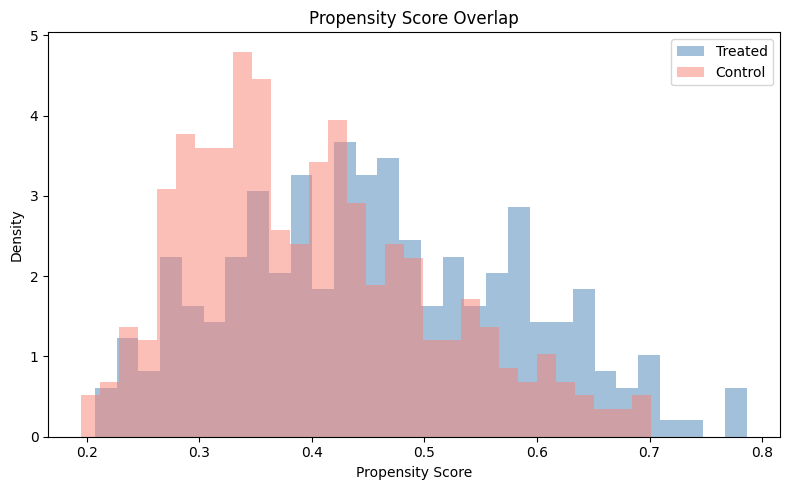

Treated PS range:  [0.207, 0.786]
Control PS range:  [0.195, 0.701]
The distributions overlap well, so the overlap assumption seems reasonable.


In [10]:
# 3. Check overlap
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df[df['D']==1]['ps'], bins=30, alpha=0.5, density=True, label='Treated', color='steelblue')
ax.hist(df[df['D']==0]['ps'], bins=30, alpha=0.5, density=True, label='Control', color='salmon')
ax.set_xlabel('Propensity Score')
ax.set_ylabel('Density')
ax.set_title('Propensity Score Overlap')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Treated PS range:  [{df[df["D"]==1]["ps"].min():.3f}, {df[df["D"]==1]["ps"].max():.3f}]')
print(f'Control PS range:  [{df[df["D"]==0]["ps"].min():.3f}, {df[df["D"]==0]["ps"].max():.3f}]')
print('The distributions overlap well, so the overlap assumption seems reasonable.')

In [11]:
# 4. IPW estimation
ps_clip = np.clip(df['ps'], 0.05, 0.95)

# Hajek estimator for ATE
ate_ipw = (df['D'] * df['weekly_active_minutes'] / ps_clip).sum() / (df['D'] / ps_clip).sum() - \
          ((1-df['D']) * df['weekly_active_minutes'] / (1-ps_clip)).sum() / ((1-df['D']) / (1-ps_clip)).sum()

# bootstrap for SE
np.random.seed(42)
boot_ates = []
for _ in range(500):
    idx = np.random.choice(len(df), len(df), replace=True)
    b = df.iloc[idx]
    lr = LogisticRegression(C=1e10, max_iter=1000)
    lr.fit(b[covs], b['D'])
    ps_b = np.clip(lr.predict_proba(b[covs])[:, 1], 0.05, 0.95)
    ate_b = (b['D'].values * b['weekly_active_minutes'].values / ps_b).sum() / (b['D'].values / ps_b).sum() - \
            ((1-b['D'].values) * b['weekly_active_minutes'].values / (1-ps_b)).sum() / ((1-b['D'].values) / (1-ps_b)).sum()
    boot_ates.append(ate_b)

se_ipw = np.std(boot_ates)
pval = 2 * (1 - stats.norm.cdf(abs(ate_ipw / se_ipw)))

# naive comparison
naive = df[df['D']==1]['weekly_active_minutes'].mean() - df[df['D']==0]['weekly_active_minutes'].mean()

# 5. Compare results
print(f'True effect:   15.00')
print(f'Naive ATE:     {naive:.2f}  (bias = {naive-15:.2f})')
print(f'IPW ATE:       {ate_ipw:.2f}  (bias = {ate_ipw-15:.2f}, SE = {se_ipw:.2f}, p = {pval:.4f})')
print()
print('The naive estimate is biased upward because treated users already have')
print('characteristics (higher plan tier, mobile, etc.) that increase active minutes.')
print('IPW corrects for this by reweighting, and the estimate is much closer to the true +15.')

True effect:   15.00
Naive ATE:     18.80  (bias = 3.80)
IPW ATE:       15.33  (bias = 0.33, SE = 1.02, p = 0.0000)

The naive estimate is biased upward because treated users already have
characteristics (higher plan tier, mobile, etc.) that increase active minutes.
IPW corrects for this by reweighting, and the estimate is much closer to the true +15.
